In [1]:
using DifferentialEquations, LinearAlgebra, Plots

In [2]:
# Basis states
r = [0; 1]  # Assume |1>
g = [1; 0]  # Assume |0>

#Initial state
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ρ_0 = complex(kron(ψ_a,ψ_1) * kron(ψ_a,ψ_1)')

4×4 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im

In [3]:
struct parameters
    Ω::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V_nn::Float64     
 end

In [311]:
function (p::parameters)(t)
    Δ0 = 3000
    δ = -100
    return (Δ0+δ*t,p.Ω, p.γ_Decay, p.γ_dephase, p.V_nn)
end

p = parameters(20,1,0,-2000)

parameters(20.0, 1.0, 0.0, -2000.0)

In [312]:
p(1)

(2900, 20.0, 1.0, 0.0, -2000.0)

In [313]:
function master_eqn(dρ,ρ,p,t)

    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Δ_t, Ω, γ_Decay, γ_dephase, V_nn = p(t)
    
    #Hamiltonian
    H = Ω/2 .* kron(I,σ_x) + Δ_t .* kron(I,n) + V_nn .* kron(n,n)
    l_decay = γ_Decay .* (kron(I,σ_minus) * ρ * kron(I,σ_plus) - 0.5.*((kron(I,σ_plus) * kron(I,σ_minus) * ρ) + (ρ * kron(I,σ_plus) * kron(I,σ_minus))))
    l_dephase = γ_dephase .* (kron(I,σ_z) * ρ * kron(I,σ_z) - ρ)

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase

end

master_eqn (generic function with 1 method)

In [314]:
# struct parameters
#     Ω::Float64     
#     γ_Decay::Float64     
#     γ_dephase::Float64
#     V_nn::Float64     
#  end
# function (p::parameters)(t)
#     Δ0 = 2400
#     δ = -1000
#     return (Δ0+δ*t,p.Ω, p.γ_Decay, p.γ_dephase, p.V_nn)
# end

# p = parameters(20,0,0,-2000)

# # Basis states
# r = [0; 1]  # Assume |1>
# g = [1; 0]  # Assume |0>

# #Initial state
# α = 1
# β = sqrt(1-α^2)
# ψ_a = α.*r + β.*g
# ψ_1 = g

# ρ_0 = complex(kron(ψ_a,ψ_1) * kron(ψ_a,ψ_1)')

# function master_eqn(dρ,ρ,p,t)

#     #2x2 Matrices
#     σ_x = [0 1; 1 0]
#     n = [0 0; 0 1]
#     I = [1 0; 0 1]
#     σ_minus = [0 1; 0 0]
#     σ_plus = [0 0; 1 0]
#     σ_z = [1 0; 0 -1]

#     #parameters
#     Δ_t, Ω, γ_Decay, γ_dephase, V_nn = p(t)
    
#     #Hamiltonian
#     H = Ω/2 .* kron(I,σ_x) + Δ_t .* kron(I,n) - V_nn .* kron(n,n)
#     l_decay = γ_Decay .* (kron(I,σ_minus) * ρ * kron(I,σ_plus) - 0.5.*((kron(I,σ_plus) * kron(I,σ_minus) * ρ) + (ρ * kron(I,σ_plus) * kron(I,σ_minus))))
#     l_dephase = γ_dephase .* (kron(I,σ_z) * ρ * kron(I,σ_z) - ρ)

#     dρ[1] .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
#     dρ[2] = 0

# end
# tspan = (0.0,5.0)

# #solving diff master_eqn
# eqn = ODEProblem(master_eqn,ρ_0,tspan,p)
# sol = solve(eqn,Tsit5(),saveat = 1.0)
# println(sol[end])

In [316]:
# 2*(Δ0+V_nn)/δ

In [317]:
# Time span and solve the problem
tspan = (0.0, 20)
eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
sol = solve(eqn, Tsit5(), saveat=0.01)
println(sol[end])

ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.9998424079555503 + 0.0im 0.010240319610609144 - 0.006055621556929699im; 0.0 + 0.0im 0.0 + 0.0im 0.010240319610609144 + 0.006055621556929699im 0.00015759204445430113 + 0.0im]


In [318]:
tr(sol.u[end])

1.0000000000000047 + 0.0im

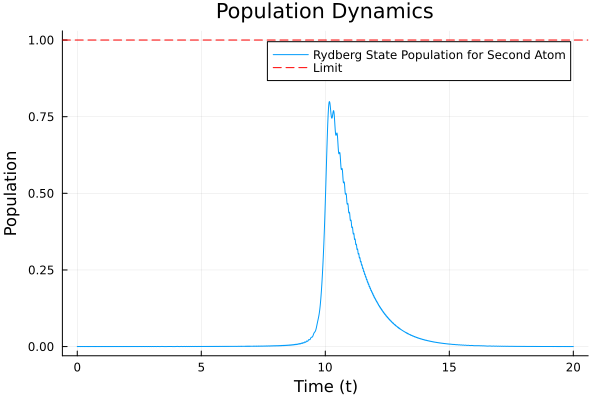

In [319]:
# Extracting populations from the solution
n = [0 0; 0 1]
I = [1 0; 0 1]

rydberg_populations = [tr(kron(I,n)*ρ) for ρ in sol.u]

# Plotting the Rydberg state population over time
plot(sol.t, real(rydberg_populations), label="Rydberg State Population for Second Atom", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")
hline!([1],color=:red,linestyle=:dash,label="Limit")

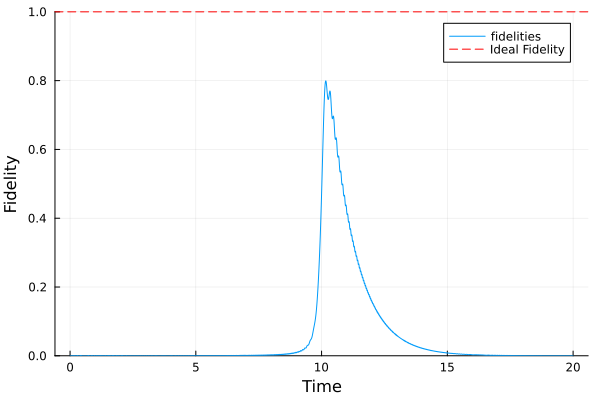

In [320]:
ψ_ideal = α*kron(r,r) + β*kron(g,g)

fidelities = []
time = []
for (t,ρ) in zip(sol.t,sol.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1))
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

In [321]:
ΔT = []
for t in range(0,20)
    push!(ΔT,p(t)[1])
end
plot(time,ΔT,label="detuning",xaxis="Time",yaxis="Δ",title="Detuning")

attempt to save state beyond implementation limit
attempt to save state beyond implementation limit


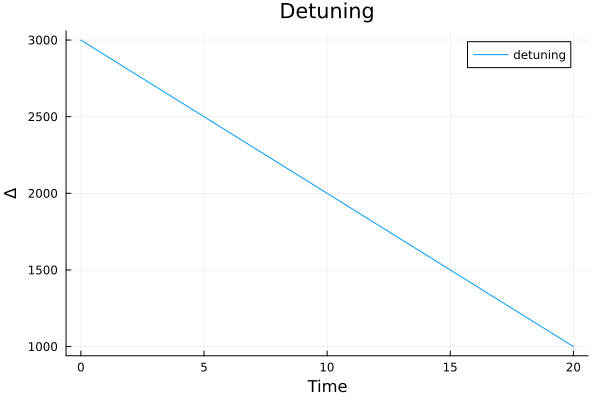

attempt to save state beyond implementation limit


In [322]:
plot(range(tspan[1],tspan[2]),ΔT,label="detuning",xaxis="Time",yaxis="Δ",title="Detuning")

## pLOTS

In [333]:
decay = collect(range(0.0,stop=1.0,step=0.1))
dephase = collect(range(0.0,stop=1.0,step=0.1))

fidelity = Array{Float64}(undef, length(decay), length(dephase))
for (i,a) in enumerate(decay)
    for (j,b) in enumerate(dephase)

        p = parameters(20,a,b,-2000)
        tspan = (0.0, 20)
        eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
        sol = solve(eqn, Tsit5(), saveat=0.01)
        
        ψ_ideal = α*kron(r,r) + β*kron(g,g)
        f = tr(ψ_ideal' * sol[end] * ψ_ideal)
        
        fidelity[i,j] = real(f) 
        
    end
end

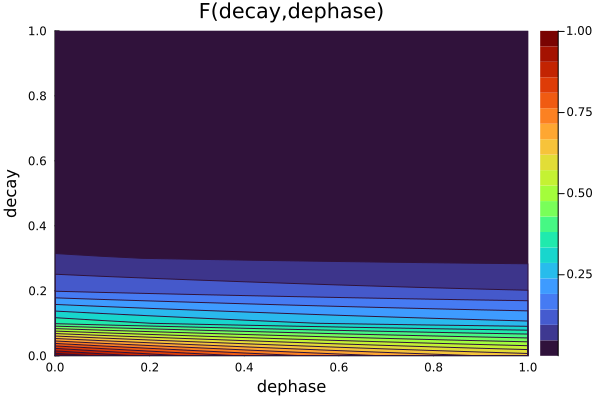

In [342]:
contourf(dephase,decay,fidelity,levels=20,color=:turbo)
title!("F(decay,dephase)")
xlabel!("dephase")
ylabel!("decay")

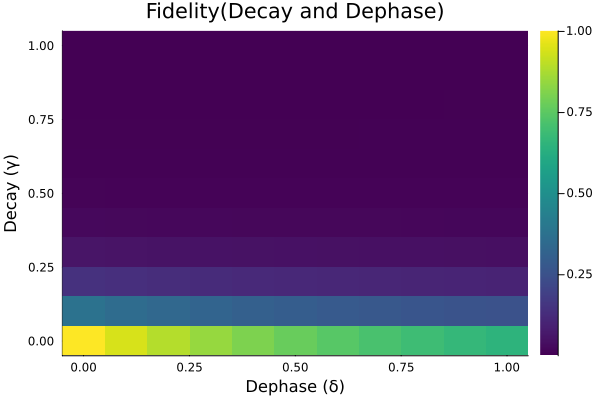

In [344]:
heatmap(dephase, decay, fidelity,
        xlabel="Dephase (δ)",
        ylabel="Decay (γ)",
        title="Fidelity(Decay and Dephase)",
        color=:viridis)